# ch5: classification-model training & Evaluation

### knn = k-nearest neighbors algorithm

In [ ]:
1. data preparation
2. choose k
3. compute distance
4. identify neighbors
5. make pridiction

In [5]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [7]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [14]:
x=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]        # df.iloc[:,0:8]
y=df['Outcome']     # df.iloc[:,-1]

In [15]:
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(614, 8)
(614,)
(154, 8)
(154,)


In [18]:
from sklearn.model_selection import train_test_split
model = KNeighborsClassifier(n_neighbors=15)
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


# OR

In [19]:
from sklearn.model_selection import train_test_split
nn=KNeighborsClassifier(n_neighbors=15)   # n_neighbors=value of K = nearest particals
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [21]:
diff=pd.DataFrame({'Actual':y_test,"predicted":prediction})
diff

,Actual,predicted
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [29]:
diff.to_csv('diabetes_data.csv')

In [30]:
diff.to_excel('diabetes_data.xlsx')

In [49]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[89 10]
 [23 32]]


<Figure size 400x400 with 0 Axes>

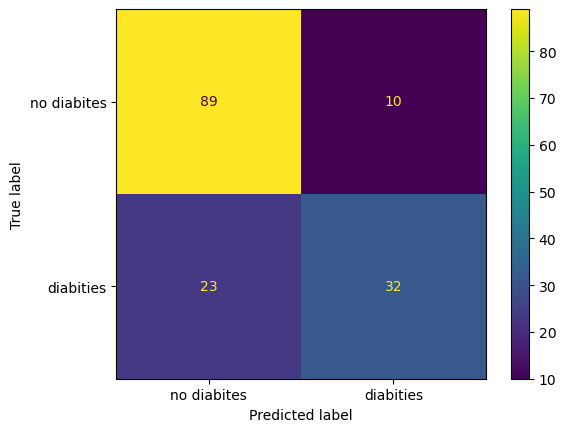

In [46]:
import matplotlib.pyplot as plt
from sklearn import metrics
plt.figure(figsize=(4,4))
cm_disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['no diabites','diabities'])
cm_disp.plot()
plt.show()

In [ ]:

0 0 = Truenagative TN
1 0 = FP
1 0 = FN
1 1 = TP

In [50]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

In [52]:
print(TN,FP,FN,TP)

89 10 23 32


In [58]:
Model_Accuracy=(TP+TN)/(TP+FP+FN+TN)

# OR

In [61]:
MA=(TP+TN)/len(x_test)

In [62]:
print(Model_Accuracy)

0.7857142857142857


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
acc=[]
for i in range(1,30):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x_train,y_train)
    prediction=model.predict(x_test)
    cm=confusion_matrix(y_test,prediction)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    Model_Accuracy=(TP+TN)/(TP+FP+FN+TN)
    acc.append(Model_Accuracy)
    

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
acc=[]
for i in range(1,30):
    nn=KNeighborsClassifier(n_neighbors=15)
    model=nn.fit(x_train,y_train)
    prediction=model.predict(x_test)
    cm=confusion_matrix(y_test,prediction)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    Model_Accuracy=(TP+TN)/(TP+FP+FN+TN)
    acc.append(Model_Accuracy)
    

In [87]:
print(acc)

[np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7857142857142857)]


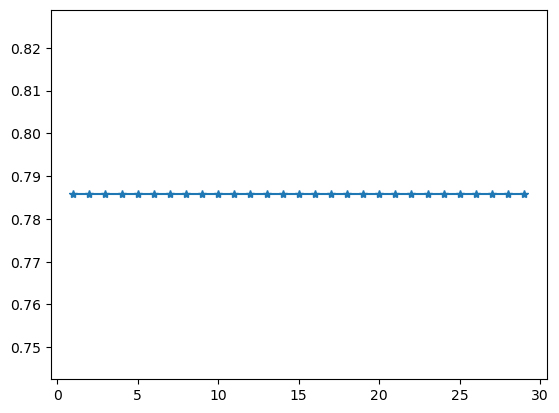

In [88]:
plt.plot(range(1,30),acc,marker="*")
plt.show()

In [89]:
from sklearn.metrics import accuracy_score
print("Accuracy score:" , accuracy_score(y_test,prediction))

Accuracy score: 0.7857142857142857


# Error rate  :  1 - Model_Accuracy      or     (FP+FN)/(TP+TN+FP+FN)

In [90]:
error_rate=1-(accuracy_score(y_test,prediction))
print("error rate:",error_rate)

error rate: 0.2142857142857143


In [91]:
error_rate=(FP+FN)/(TP+TN+FP+FN)
print("error rate:",error_rate)

error rate: 0.21428571428571427


# Sensitivity = TP / (TP + FN)

In [92]:
print("sensitivity:",TP / (TP + FN))

sensitivity: 0.5818181818181818


In [93]:
from sklearn.metrics import recall_score
print("sensitivity:",recall_score(y_test,prediction))

sensitivity: 0.5818181818181818


# Specificity :  (TN)/(TN+FP)

In [94]:
print("specificity:",(TN)/(TN+FP))

specificity: 0.898989898989899


In [95]:
from sklearn.metrics import recall_score
print("specificity:",recall_score(y_test,prediction,pos_label=0))   # poss label for calculate nagative 

specificity: 0.898989898989899


# Precision_Score :  (TP)/(TP+FP)

In [99]:
print("Precision_Score:",(TP)/(TP+FP))

specificity: 0.7619047619047619


In [101]:
from sklearn.metrics import precision_score
print("Precision_Score:",precision_score(y_test,prediction,))

Precision_Score: 0.7619047619047619


In [102]:
import pandas as pd
df=pd.read_csv("tshirt.csv")
df

,Height,Wight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M
5,163,60,M
6,163,61,M
7,160,64,L
8,163,64,L
9,165,61,L
